# Darukaa Adaptive Biodiversity Assessment — Nandoshi Lake (R4 reference architecture)

**Purpose:** complete Colab workflow for the aquatic/lake profile, from repository installation and Google Earth Engine authentication through geometry QA, automatically derived water domains, aquatic metrics, readiness checks, provenance, and baseline/monitoring comparison.

### Critical spatial rule
The uploaded KML is the **fixed master assessment boundary**. The pipeline does **not** require a hand-drawn water mask. Water surface is derived dynamically from Earth observation for each analysis period. The same KML is not treated as the ecological mask for every metric.

### Output philosophy
Raw measurements, temporal windows, spatial domains, dataset names, observation counts and QA flags are retained. Aquatic proxies without an approved ecological threshold are **not silently converted into a composite concern score**. Composite aquatic State-of-Nature scoring is disabled by default.

## Reference-selection architecture (general framework)
This Nandoshi notebook exercises the **aquatic profile** of the general v1.1.0 reference engine. Nandoshi is a validation site, not the source of ecosystem-specific rules. The same decision contract is used for terrestrial and mixed assessments: ecological eligibility is defined by the applicable realm profile first; HMI then identifies the least-disturbed candidates within that eligible population. The engine does not trade ecological mismatch against lower HMI through a weighted score and does not keep relaxing criteria indefinitely.

**Finite decision contract:** strict low-pressure → empirical least-disturbed HMI quantile → one explicit manual HMI threshold → reference unavailable.

For aquatic sites, the current eligibility profile uses ecoregion + water-occurrence regime. For terrestrial sites, it uses ecoregion + habitat stratum. Mixed assessments maintain separate domain-specific reference populations.

## 0. Reproducibility checklist

For a client-grade run, pin the repository to an exact Git commit, retain the uploaded KML, record the GEE project, keep the generated `assessment_manifest.json`, and use the same profile/configuration for baseline and monitoring runs. The old reference package is preserved under `legacy/` and is not overwritten by this lake profile.

In [1]:
# Configuration for the Colab run
REPO_URL = "https://github.com/G-auravSingh/reference-benchmarking.git"
GIT_REF = "main"  # For a final client run, replace with the exact verified commit SHA printed below.
REPO_DIR = "/content/reference-benchmarking"
ADAPTIVE_DIR = f"{REPO_DIR}/darukaa_adaptive_v1.1.0"
PROFILE_PATH = f"{ADAPTIVE_DIR}/profiles/aquatic_lake.yaml"
GEE_PROJECT = "clever-grid-229708"  # Change only if your EE project differs.

EXPECTED_PACKAGE_VERSION = "1.1.0"

# Optional finite Stage-C fallback. Leave None for the automatic A→B pathway.
# Only use this after the checkpoint reports that strict and least-disturbed
# contemporary selection both failed. Choose the threshold from the reported
# HMI distribution/threshold-retention diagnostics; do not choose it merely to
# force a reference to exist. Example: 0.30 means candidate pixels with HMI <= 0.30.
MANUAL_REFERENCE_HMI_THRESHOLD = None
MANUAL_REFERENCE_HMI_STATE = "best_attainable"


In [2]:
# Cleanly obtain the repository and install ONLY the current v1.1.0 package.
# This avoids stale package shadowing from previous Colab cells/runtimes.
import os, subprocess, sys, pathlib, shutil

def run_cmd(cmd, cwd=None):
    print("$", " ".join(cmd))
    r = subprocess.run(cmd, cwd=cwd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(r.stdout)
    r.check_returncode()

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
run_cmd(["git", "clone", "--depth", "1", "--branch", GIT_REF, REPO_URL, REPO_DIR])

if not os.path.isdir(ADAPTIVE_DIR):
    raise FileNotFoundError(f"Current adaptive package not found: {ADAPTIVE_DIR}")
run_cmd([sys.executable, "-m", "pip", "install", "-q", "-r", f"{ADAPTIVE_DIR}/requirements.txt"])
run_cmd([sys.executable, "-m", "pip", "install", "-q", "-e", ADAPTIVE_DIR])

sys.path.insert(0, ADAPTIVE_DIR)
for name in list(sys.modules):
    if name == "darukaa_adaptive" or name.startswith("darukaa_adaptive."):
        del sys.modules[name]


$ git clone --depth 1 --branch main https://github.com/G-auravSingh/reference-benchmarking.git /content/reference-benchmarking
Cloning into '/content/reference-benchmarking'...

$ /usr/bin/python3 -m pip install -q -r /content/reference-benchmarking/darukaa_adaptive_v1.1.0/requirements.txt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.4/114.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.4 MB/s eta 0:00:00

$ /usr/bin/python3 -m pip install -q -e /content/reference-benchmarking/darukaa_adaptive_v1.1.0



In [3]:
# Release identity and stale-package guard.
import subprocess, pathlib, sys, os
import darukaa_adaptive

git_sha = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip()
package_file = pathlib.Path(darukaa_adaptive.__file__).resolve()

print("Repository commit:", git_sha)
print("Package version:", darukaa_adaptive.__version__)
print("Imported package:", package_file)
print("Expected package root:", pathlib.Path(ADAPTIVE_DIR).resolve())

assert darukaa_adaptive.__version__ == EXPECTED_PACKAGE_VERSION
assert pathlib.Path(ADAPTIVE_DIR).resolve() in package_file.parents
assert pathlib.Path(PROFILE_PATH).exists()
assert (pathlib.Path(ADAPTIVE_DIR) / "darukaa_adaptive" / "reference_condition.py").exists()
assert (pathlib.Path(ADAPTIVE_DIR) / "darukaa_adaptive" / "reference_engine.py").exists()
print("✓ v1.1.0 package/path/profile/reference-module checks passed")
print("For a client run, retain this exact SHA with the KML and output bundle.")

os.environ["DARUKAA_GIT_COMMIT"] = git_sha


Repository commit: d7b3adc0688901ea36a022652eaf37e26234995f
Package version: 1.1.0
Imported package: /content/reference-benchmarking/darukaa_adaptive_v1.1.0/darukaa_adaptive/__init__.py
Expected package root: /content/reference-benchmarking/darukaa_adaptive_v1.1.0
✓ v1.1.0 package/path/profile/reference-module checks passed
For a client run, retain this exact SHA with the KML and output bundle.


## 1. Google Earth Engine authentication

In [4]:
import ee

try:
    ee.Initialize(project=GEE_PROJECT)
    print("Earth Engine is already initialized:", GEE_PROJECT)
except Exception as e:
    print("Authentication/initialization required:", e)
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print("Earth Engine initialized:", GEE_PROJECT)


Authentication/initialization required: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine initialized: clever-grid-229708


In [5]:
# Confirm that the public datasets used by the full lake profile can be opened.
# TNC HM v3 is an ImageCollection even though the configured product is a static snapshot.
checks = {
    "Dynamic World": ("ImageCollection", "GOOGLE/DYNAMICWORLD/V1"),
    "Sentinel-2 SR Harmonized": ("ImageCollection", "COPERNICUS/S2_SR_HARMONIZED"),
    "Sentinel-1 GRD": ("ImageCollection", "COPERNICUS/S1_GRD"),
    "TNC Global Human Modification v3 90m static": ("ImageCollection", "TNC/HM/v3/90m_s"),
    "RESOLVE Ecoregions 2017": ("FeatureCollection", "RESOLVE/ECOREGIONS/2017"),
    "JRC Global Surface Water (historical context)": ("Image", "JRC/GSW1_4/GlobalSurfaceWater"),
}
constructors = {"ImageCollection": ee.ImageCollection, "FeatureCollection": ee.FeatureCollection, "Image": ee.Image}
for label, (kind, asset) in checks.items():
    try:
        constructors[kind](asset)
        print(f"✓ {label}: {kind} {asset}")
    except Exception as e:
        raise RuntimeError(f"Dataset preflight failed for {label} ({asset}): {e}") from e

# Verify the critical reference dataset band explicitly.
hmi_col = ee.ImageCollection("TNC/HM/v3/90m_s")
hmi_count = hmi_col.size().getInfo()
if hmi_count < 1:
    raise RuntimeError("TNC/HM/v3/90m_s contains no accessible images in the public catalog.")
hmi_bands = ee.Image(hmi_col.first()).bandNames().getInfo()
if "All_threats_combined" not in hmi_bands:
    raise RuntimeError(f"Expected HMI band not found. Available bands: {hmi_bands}")
print("✓ TNC HMI image count:", hmi_count, "| bands:", hmi_bands)


✓ Dynamic World: ImageCollection GOOGLE/DYNAMICWORLD/V1
✓ Sentinel-2 SR Harmonized: ImageCollection COPERNICUS/S2_SR_HARMONIZED
✓ Sentinel-1 GRD: ImageCollection COPERNICUS/S1_GRD
✓ TNC Global Human Modification v3 90m static: ImageCollection TNC/HM/v3/90m_s
✓ RESOLVE Ecoregions 2017: FeatureCollection RESOLVE/ECOREGIONS/2017
✓ JRC Global Surface Water (historical context): Image JRC/GSW1_4/GlobalSurfaceWater
✓ TNC HMI image count: 1 | bands: ['All_threats_combined', 'Agriculture', 'Built_up', 'Energy_production_and_mining', 'Biological_resource_use', 'Human_accessibility', 'Natural_system_modification', 'Pollution', 'Transportation_and_service_corridors']


**Dataset note:** Dynamic World is a 10 m near-real-time land-cover product; Sentinel-2 SR Harmonized is available from 2017 onward; Sentinel-1 GRD provides radar observations; JRC Global Surface Water v1.4 contains mapped water history through 2021 and is therefore treated only as historical context in this release.

## 2. Upload the master project KML

In [6]:
from google.colab import files
from pathlib import Path

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("Upload the project KML/KMZ to continue.")

allowed={".kml",".kmz"}
site_candidates=[Path(name) for name in uploaded if Path(name).suffix.lower() in allowed]
if not site_candidates:
    raise ValueError("No .kml or .kmz file was uploaded.")
SITE_FILE=str(site_candidates[0])
print("Using site boundary:", SITE_FILE)


Saving Nandoshi lake.kml to Nandoshi lake.kml
Using site boundary: Nandoshi lake.kml


## 3. Load geometry and run spatial QA

In [7]:
from darukaa_adaptive.site import read_kml, area_ha, make_domains, geometry_hash

geom, named_parts = read_kml(SITE_FILE)
print("Named geometry parts:", len(named_parts))
print("Part names:", list(named_parts)[:20])
print(f"Master boundary area: {area_ha(geom):.4f} ha")
print("KML SHA-256:", geometry_hash(SITE_FILE))
print("Bounds:", tuple(round(x,6) for x in geom.bounds))


Named geometry parts: 1
Part names: ['Nandoshi lake']
Master boundary area: 8.7798 ha
KML SHA-256: 432331b3be0b0aa23b4beba81301fd62f1ff5f197c2a16abfb4583b4e0088e98
Bounds: (74.294524, 17.525978, 74.298297, 17.529033)


In [8]:
# Load and validate the exact v1.1.0 aquatic profile before any expensive EE analysis.
from darukaa_adaptive.config import AssessmentConfig
import pandas as pd
cfg = AssessmentConfig.from_yaml(PROFILE_PATH)
cfg.gee.project_id = GEE_PROJECT
cfg.reference.manual_hmi_threshold = MANUAL_REFERENCE_HMI_THRESHOLD
cfg.reference.manual_hmi_reference_state = MANUAL_REFERENCE_HMI_STATE
errors = cfg.validate()
if errors:
    raise ValueError("Profile validation failed:\n- " + "\n- ".join(errors))
BASELINE_START, BASELINE_END = cfg.temporal.baseline_dates()
print("✓ configuration validated")
print("Profile version:", cfg.profile.version)
print("Baseline window (GEE exclusive end):", BASELINE_START, "to", BASELINE_END)
print("Baseline label:", cfg.temporal.baseline_label)
print("Trend window:", cfg.temporal.start_year, "to", cfg.temporal.end_year)
print("Reference search radius (km):", cfg.reference.search_radius_km)
print("Reference escalation: strict low-pressure → least-disturbed quantile → optional manual HMI threshold → terminal unavailable")
print("Strict HMI threshold:", cfg.reference.hmi_max_for_reference)
print("Least-disturbed quantile:", cfg.reference.least_disturbed_quantile)
print("Manual HMI fallback threshold:", cfg.reference.manual_hmi_threshold)
print("Automatic reference enabled:", cfg.reference.automatic_enabled)
print("Automatic approval permission (QA-gated):", cfg.reference.auto_approve)
print("HMI asset/band:", cfg.reference.hmi_gee_asset, cfg.reference.hmi_gee_band)


✓ configuration validated
Profile version: 1.1.0
Baseline window (GEE exclusive end): 2025-08-01 to 2026-09-01
Baseline label: Year-0 (Aug 2025-Aug 2026)
Trend window: 2018 to 2026
Reference search radius (km): 25.0
Reference state: least_disturbed_contemporary
Automatic reference enabled: True
Automatic approval permission (QA-gated): True
HMI asset/band: TNC/HM/v3/90m_s All_threats_combined


In [9]:
# Create the fixed spatial domains.
from darukaa_adaptive.site import ee_geometry

domains=make_domains(geom,cfg.spatial.riparian_buffer_m,cfg.spatial.context_buffer_km)
print("Fixed domains created:")
print("  master boundary")
print(f"  riparian buffer: {cfg.spatial.riparian_buffer_m:.0f} m outside master boundary")
print(f"  context: {cfg.spatial.context_buffer_km:.1f} km outside master boundary")
print("Dynamic water domain is generated later from EO observations.")


Fixed domains created:
  master boundary
  riparian buffer: 100 m outside master boundary
  context: 5.0 km outside master boundary
Dynamic water domain is generated later from EO observations.


### Spatial interpretation
The pipeline cannot infer whether the KML was originally intended to represent a lake outline, project boundary, intervention area, or another feature. In the absence of metadata, this release treats it as the **master assessment boundary** and records that assumption in the manifest.

A dynamic water mask is therefore derived *inside that master boundary* and can vary by date/period. Exposed pixels are not automatically labelled as terrestrial habitat.

## 4. Interactive view of the fixed domains

In [10]:
import geemap

m=geemap.Map()
m.centerObject(domains["boundary"], 14)
m.addLayer(domains["boundary"], {"color":"red"}, "Master boundary")
m.addLayer(domains["riparian_fixed"], {"color":"yellow"}, "Fixed 100 m riparian ring")
m.addLayer(domains["context"], {"color":"cyan"}, "5 km context")
m


Map(center=[17.52762396694401, 74.29619075001696], controls=(WidgetControl(options=['position', 'transparent_b…

## 5. Dynamic water detector

In [11]:
from darukaa_adaptive.water import WaterDetector
water = WaterDetector(cfg)

# Exploratory full historical window for water dynamics. The production metric suite
# below uses the explicit Year-0 baseline window from the profile.
RUN_START, RUN_END = cfg.temporal.trend_dates()
print("Exploratory water window:", RUN_START, "to", RUN_END)
print("Production baseline window:", BASELINE_START, "to", BASELINE_END)
print("Primary method:", cfg.water.primary_dataset)
print("Primary water probability threshold:", cfg.water.primary_probability_threshold)


Exploratory water window: 2018-01-01 to 2027-01-01
Production baseline window: 2025-08-01 to 2026-09-01
Primary method: GOOGLE/DYNAMICWORLD/V1
Primary water probability threshold: 0.5


In [12]:
# Dynamic water extent for the configured analysis window.
water_summary=water.area_summary(domains["boundary"],RUN_START,RUN_END)
water_summary


{'period_start': '2018-01-01',
 'period_end': '2027-01-01',
 'period_end_inclusive': '2026-12-31',
 'images_used': 361,
 'method': 'dynamic_world_probability',
 'water_area_ha': 2.418268970489502,
 'boundary_area_ha': 8.784116050711239,
 'water_fraction_pct': 27.530020738896066,
 'occurrence_fraction': 0.5980395090686389,
 'water_present': True,
 'status': 'ok',
 'notes': 'Water extent is descriptive and must be compared using the same seasonal/temporal window.'}

### The important quantity
`water_fraction_pct` is the EO-derived water area as a percentage of the fixed master boundary for the requested period. It is a **monitoring quantity**, not a universal “higher is better” condition score because lake hydroperiod is system-specific.

## 6. Monthly dynamic-water series for the configured Year-0 baseline


In [13]:
# Monthly water extent is aligned to the configured Year-0 baseline and monitoring months.
# This avoids showing future months as zero when the notebook is run before the calendar year ends.
from datetime import date

baseline_start_raw = cfg.temporal.baseline_start_date
baseline_end_raw = cfg.temporal.baseline_end_date
baseline_start_date = baseline_start_raw if isinstance(baseline_start_raw, date) else date.fromisoformat(str(baseline_start_raw))
baseline_end_date = baseline_end_raw if isinstance(baseline_end_raw, date) else date.fromisoformat(str(baseline_end_raw))
monitoring_months = list(cfg.temporal.monitoring_months)

def baseline_month_periods(start_date, end_date, months):
    periods = []
    # Walk the configured monitoring cycle from baseline start, retaining months
    # that overlap the inclusive Year-0 baseline and never extending beyond it.
    cursor = start_date.replace(day=1)
    while cursor <= end_date:
        if cursor.month in months:
            if cursor.month == 12:
                next_month = date(cursor.year + 1, 1, 1)
            else:
                next_month = date(cursor.year, cursor.month + 1, 1)
            period_start = max(cursor, start_date)
            period_end = min(next_month, date.fromordinal(end_date.toordinal() + 1))
            if period_start < period_end:
                periods.append({
                    "label": cursor.strftime("%Y-%m"),
                    "start": period_start.isoformat(),
                    "end": period_end.isoformat(),
                })
        if cursor.month == 12:
            cursor = date(cursor.year + 1, 1, 1)
        else:
            cursor = date(cursor.year, cursor.month + 1, 1)
    return periods

monthly = []
for p in baseline_month_periods(baseline_start_date, baseline_end_date, monitoring_months):
    r = water.area_summary(domains["boundary"], p["start"], p["end"])
    r["period"] = p["label"]
    monthly.append(r)

monthly_df = pd.DataFrame(monthly)
monthly_df[["period", "water_area_ha", "water_fraction_pct", "images_used", "method", "status"]]


,period,water_area_ha,water_fraction_pct,images_used,method,status
0,2025-08,5.304601,60.388558,3,sentinel1_vv_majority,ok
1,2025-09,6.238362,71.018662,2,sentinel1_vv_majority,ok
2,2025-10,8.043220,91.565500,3,dynamic_world_probability,ok
3,2025-11,7.965346,90.678967,5,dynamic_world_probability,ok
4,2025-12,7.381428,84.031546,6,dynamic_world_probability,ok
5,2026-01,5.910536,67.286629,7,dynamic_world_probability,ok
6,2026-02,3.812326,43.400226,5,dynamic_world_probability,ok
7,2026-03,1.299228,14.790654,7,dynamic_world_probability,ok
8,2026-04,0.407788,4.642328,7,dynamic_world_probability,ok
9,2026-05,0.000000,0.000000,5,dynamic_world_probability,ok


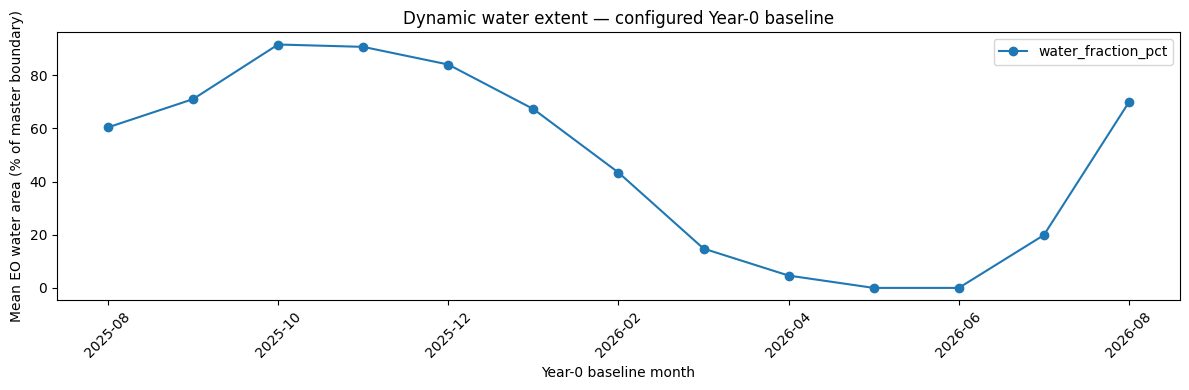

In [14]:
import matplotlib.pyplot as plt

ax=monthly_df.plot(x="period",y="water_fraction_pct",kind="line",marker="o",figsize=(12,4))
ax.set_ylabel("Mean EO water area (% of master boundary)")
ax.set_xlabel("Year-0 baseline month")
ax.set_title("Dynamic water extent — configured Year-0 baseline")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Visualize one automatically derived water mask

In [15]:
# Inspect the final configured baseline month (August 2026 for the current Year-0 window).
selected_start = baseline_end_date.replace(day=1).isoformat()
selected_end = (date(baseline_end_date.year + (1 if baseline_end_date.month == 12 else 0),
                     1 if baseline_end_date.month == 12 else baseline_end_date.month + 1, 1)).isoformat()
selected_end = min(selected_end, date.fromordinal(baseline_end_date.toordinal() + 1).isoformat())
mask,method,n_images=water.water_mask_for_period(domains["boundary"],selected_start,selected_end)
print("Period:",selected_start,selected_end,"| method:",method,"| observations:",n_images)

mw=geemap.Map()
mw.centerObject(domains["boundary"],14)
mw.addLayer(domains["boundary"],{"color":"red"},"Master boundary")
mw.addLayer(mask.selfMask(),{"palette":["0000FF"]},"Dynamic water mask")
mw


Period: 2026-08-01 2026-09-01 | method: sentinel1_vv_majority | observations: 2


Map(center=[17.527623966925873, 74.29619074999319], controls=(WidgetControl(options=['position', 'transparent_…

The blue layer in the map is produced by the detector from Earth Engine imagery for the selected period. It is not a manually supplied secondary geometry.

## 8. Long-window water persistence

In [16]:
persistence=water.persistence(domains["boundary"],RUN_START,RUN_END)
persistence


{'period_start': '2018-01-01',
 'period_end': '2027-01-01',
 'method': 'dynamic_world_label',
 'n_images': 361,
 'water_occurrence_fraction': 0.5980395090686389,
 'status': 'ok',
 'stats': {'mean': 0.5980395090686389,
  'std_dev': 0.22490907290996587,
  'p05': 0.2226027397260274,
  'p10': 0.3016194918475113,
  'p25': 0.450607939254133,
  'p50': 0.6079109339814358,
  'p75': 0.7712298154555941,
  'p90': 0.8767274283879714,
  'p95': 0.899998810925219,
  'count': 1002}}

Water persistence is the spatial mean of the fraction of valid Dynamic World observations classified as water. It should be interpreted together with the observation count and the analysis window.

## 9. Run the lake metric suite

In [17]:
# Run the COMPLETE v1.1.0 adaptive pipeline once.
# Production path: metrics → measurement QA → reference construction/QA → benchmarking → scoring → readiness → report.
from darukaa_adaptive import AdaptivePipeline
import pandas as pd

pipeline = AdaptivePipeline(cfg)
result = pipeline.run(SITE_FILE)

metric_results = result["metrics"]
metric_df = pd.DataFrame([m.to_dict() for m in metric_results])
print("✓ AdaptivePipeline completed")
print("Package version:", darukaa_adaptive.__version__)
print("Metrics:", len(metric_results))
print("Benchmarks:", len(result.get("benchmarks", [])))
print("Pillar rows:", len(result.get("pillars", [])))
print("Reference populations:", result.get("reference_populations", {}))
print("Overall scorecard:", result.get("overall", {}))

metric_df[["metric", "pillar", "domain", "value", "units", "status", "temporal_window", "dataset", "scale_m", "direction", "score_eligible"]]


✓ AdaptivePipeline completed
Package version: 1.1.0
Metrics: 8
Benchmarks: 8
Pillar rows: 4
Reference populations: {'aquatic': {'level': 'auto_aquatic', 'realm': 'aquatic', 'method': 'ecoregion_hydrology_low_pressure', 'status': 'candidate_rejected', 'candidate_area_ha': 0.0, 'candidate_pixels': 0, 'uncertainty': None, 'approval': False, 'reference_state': 'least_disturbed_contemporary', 'diagnostics': {'candidate_area_ha': 0.0, 'candidate_pixels': 0, 'minimum_area_ha': 2.0, 'minimum_pixels': 500, 'ecological_match_score': 0.0, 'minimum_ecological_match_score': 0.8, 'population_ok': False, 'area_ok': False, 'pixels_ok': False, 'candidate_area_ha_finite': True, 'ecological_match_ok': False, 'pressure_screen_ok': False, 'temporal_match_ok': True, 'spatial_quality_ok': True, 'reference_state': 'least_disturbed_contemporary', 'site_water_occurrence': 0.553591676595027, 'candidate_mean_water_occurrence': None, 'water_occurrence_tolerance': 0.25, 'minimum_water_occurrence': 0.5, 'occurrence_

,metric,pillar,domain,value,units,status,temporal_window,dataset,scale_m,direction,score_eligible
0,water_extent,C1_extent,dynamic_water,17.489679,% of master boundary,ok,2025-08-01:2026-08-31,dynamic_world_probability,10,reference_target,False
1,water_persistence,C1_extent,dynamic_water,0.553592,fraction,ok,2025-08-01:2026-08-31,dynamic_world_label,10,reference_target,False
2,ndci_proxy,C1_extent,dynamic_water,0.068219,NDCI,ok,2025-08-01:2026-08-31,COPERNICUS/S2_SR_HARMONIZED + dynamic_world_pr...,20,lower_is_better,False
3,red_reflectance_turbidity_proxy,C1_extent,dynamic_water,0.062141,surface reflectance,ok,2025-08-01:2026-08-31,COPERNICUS/S2_SR_HARMONIZED + dynamic_world_pr...,20,lower_is_better,False
4,surface_algal_bloom_frequency,C1_extent,dynamic_water,0.297325,fraction,ok,2025-08-01:2026-08-31,COPERNICUS/S2_SR_HARMONIZED + dynamic_world_pr...,20,lower_is_better,False
5,riparian_ndvi,C2_vegetation,fixed_riparian_100m,0.310044,NDVI,ok,2025-08-01:2026-08-31,COPERNICUS/S2_SR_HARMONIZED,10,higher_is_better,False
6,shoreline_disturbance_fraction,C4_pressure,fixed_riparian_100m,0.728843,fraction,ok,2025-08-01:2026-08-31,GOOGLE/DYNAMICWORLD/V1,10,lower_is_better,False
7,riparian_ndvi_sen_slope,C2_vegetation,fixed_riparian_100m,-0.002259,NDVI/year,ok,2018:2026,COPERNICUS/S2_SR_HARMONIZED,10,context_dependent,False


## Reference-condition validation checkpoint
This is mandatory for a live v1.1.0 validation. A run is not considered successful merely because the metric pipeline completes. Reference selection follows a finite, auditable pathway: (A) strict minimally-disturbed contemporary; (B) least-disturbed contemporary quantile if A has no approved population; (C) explicit manual/historical/best-attainable fallback if supplied. If all configured pathways fail, the pipeline terminates with `reference_unavailable_requires_external_reference`; it does not keep relaxing criteria indefinitely. Software execution errors remain release-blocking.

In [18]:
benchmark_df = pd.DataFrame([b.to_dict() for b in result.get("benchmarks", [])])
reference_populations = result.get("reference_populations", {})

print("REFERENCE POPULATION SUMMARY")
display(pd.DataFrame(reference_populations).T if reference_populations else pd.DataFrame())

print("REFERENCE BENCHMARKS")
ref_cols = [c for c in ["metric","selected_reference","selected_reference_level","reference_n","reference_uncertainty","relative_departure_pct","reference_attainment_0_100","reference_method","reference_state","reference_approval_basis","reference_approved_for_scoring","benchmark_status","interpretation_status"] if c in benchmark_df.columns]
display(benchmark_df[ref_cols] if not benchmark_df.empty else pd.DataFrame())

def _has_reference_error(x):
    if not isinstance(x, dict):
        return False
    return bool(x.get("error") or str(x.get("status", "")).startswith("error:"))
population_errors = [realm for realm, pop in reference_populations.items() if _has_reference_error(pop)]
benchmark_errors = []
if not benchmark_df.empty and "reference_diagnostics" in benchmark_df.columns:
    benchmark_errors = [str(r.metric) for _, r in benchmark_df.iterrows() if _has_reference_error(r.reference_diagnostics)]
if population_errors or benchmark_errors:
    raise RuntimeError(f"Reference-engine execution errors detected. populations={population_errors}; metrics={benchmark_errors}")
print("✓ No reference-engine execution errors detected.")
print("Reference escalation is finite: strict → least-disturbed quantile → optional manual HMI threshold.")
print("If both automatic stages fail, review the reported HMI distribution. If a defensible manual HMI threshold can be justified from those diagnostics, set MANUAL_REFERENCE_HMI_THRESHOLD in the configuration cell and rerun the pipeline. Otherwise the terminal result is reference_unavailable.")


REFERENCE POPULATION SUMMARY


,level,realm,method,status,candidate_area_ha,candidate_pixels,uncertainty,approval,reference_state,diagnostics
aquatic,auto_aquatic,aquatic,ecoregion_hydrology_low_pressure,candidate_rejected,0.0,0,None,False,least_disturbed_contemporary,"{'candidate_area_ha': 0.0, 'candidate_pixels':..."


REFERENCE BENCHMARKS


,metric,selected_reference,selected_reference_level,reference_n,reference_uncertainty,relative_departure_pct,reference_attainment_0_100,reference_method,reference_state,reference_approval_basis,reference_approved_for_scoring,benchmark_status,interpretation_status
0,water_extent,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
1,water_persistence,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
2,ndci_proxy,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
3,red_reflectance_turbidity_proxy,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
4,surface_algal_bloom_frequency,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
5,riparian_ndvi,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
6,shoreline_disturbance_fraction,None,none,0.0,None,None,None,ecoregion_hydrology_low_pressure,least_disturbed_contemporary,not_approved,False,reference_unavailable,reference_unavailable
7,riparian_ndvi_sen_slope,None,none,NaN,None,None,None,,,,False,not_referenceable,screening_or_contextual


✓ No automatic-reference execution errors detected. Candidate rejection, if any, is a QA result rather than a software failure.


## Stage-C manual HMI fallback — use only if Stages A and B fail

If the checkpoint reports `candidate_rejected_reference_unavailable`, review the HMI distribution and threshold-retention diagnostics printed above. If there is a defensible analyst-selected HMI threshold, enter it below. This is the final allowed escalation; it is not an automatic threshold relaxation.

Do **not** choose a value merely to make the reference pass. Record the scientific/management rationale in the run notes. After setting the value, rerun the pipeline cell and then rerun this checkpoint.


In [ ]:
# Example only — replace 0.30 with the threshold justified by the diagnostics, or leave None.
MANUAL_REFERENCE_HMI_THRESHOLD = None  # e.g. 0.30
MANUAL_REFERENCE_HMI_STATE = "best_attainable"

if MANUAL_REFERENCE_HMI_THRESHOLD is not None:
    if not 0 <= float(MANUAL_REFERENCE_HMI_THRESHOLD) <= 1:
        raise ValueError("MANUAL_REFERENCE_HMI_THRESHOLD must be between 0 and 1.")
    cfg.reference.manual_hmi_threshold = float(MANUAL_REFERENCE_HMI_THRESHOLD)
    cfg.reference.manual_hmi_reference_state = MANUAL_REFERENCE_HMI_STATE
    print("✓ Manual HMI fallback configured:", cfg.reference.manual_hmi_threshold)
    print("Rerun the AdaptivePipeline cell, then rerun the reference validation checkpoint.")
else:
    print("Manual HMI fallback remains disabled. No additional automatic stage will be attempted.")


### Interpretation guardrail
The output distinguishes `value` from `score_eligible`. A metric can be ecologically useful and still be intentionally left out of a composite score when no validated general threshold is configured.

## 10. Water-quality proxy inspection

In [19]:
display_cols=["metric","value","units","domain","status","valid_observations","notes"]
metric_df[metric_df["metric"].isin([
    "ndci_proxy","red_reflectance_turbidity_proxy","surface_algal_bloom_frequency"
])][display_cols]


,metric,value,units,domain,status,valid_observations,notes
2,ndci_proxy,0.068219,NDCI,dynamic_water,ok,57,Water-masked chlorophyll/trophic proxy. Requir...
3,red_reflectance_turbidity_proxy,0.062141,surface reflectance,dynamic_water,ok,57,Water-masked red-band proxy. Do not report as ...
4,surface_algal_bloom_frequency,0.297325,fraction,dynamic_water,ok,57,FAI bloom-proxy frequency using threshold 0.00...


NDCI and FAI-derived values are optical proxies. Their raw values can be used for repeat monitoring with identical processing, but a project should not turn them into a universal “poor/good” score without calibration to local water conditions or an externally approved threshold protocol.

## 11. Standardized riparian disturbance

In [20]:
metric_df[metric_df["metric"]=="shoreline_disturbance_fraction"][display_cols]


,metric,value,units,domain,status,valid_observations,notes
6,shoreline_disturbance_fraction,0.728843,fraction,fixed_riparian_100m,ok,49,"Share of the fixed 100 m ring mapped as crops,..."


This indicator uses the automatically generated fixed 100 m riparian ring outside the master boundary. It reports the fraction mapped as crops, built area, or bare ground. It is a contextual pressure metric, not a direct measurement of biodiversity loss.

## 12. Multi-year riparian NDVI trend

In [ ]:
metric_df[metric_df["metric"]=="riparian_ndvi_sen_slope"][display_cols]


The trend uses annual seasonal composites and a Theil–Sen slope. Kendall tau significance is retained in the metric notes. A minimum temporal-depth gate prevents a short two-year series from being described as a long-term trend.

## 13. Readiness checks

In [21]:
# Use the readiness result produced by the complete adaptive pipeline.
readiness = result["readiness"]
readiness


{'geometry': {'status': 'ready',
  'boundary_area_ha': 8.779842,
  'boundary_type': 'assessment_boundary'},
 'temporal_baseline': {'status': 'configured',
  'label': 'Year-0 (Aug 2025-Aug 2026)',
  'start': '2025-08-01',
  'end': '2026-08-31'},
 'historical_context': {'start_year': 2018,
  'end_year': 2026,
  'minimum_years_for_trend': 5},
 'metric_coverage': {'total_metrics': 8,
  'usable_metrics': 8,
  'referenceable_metrics': 7},
 'reference_readiness': {'status': 'partial_or_unavailable',
  'benchmarked_metrics': 0,
  'automatic_reference_enabled': True,
  'automatic_reference_approval_is_QA_gated': True,
  'manual_reference_optional': True},
 'evidence': {'types_available': [],
  'edna_optional': True,
  'note': 'eDNA is integrated only when supplied and validated; persistence-potential proxies remain contextual unless a defensible scoring reference is provided.'},
 'scoring': {'condition_pressure_separated': True,
  'condition_min_pillars': 3,
  'composite_son_enabled': False,
  

The readiness block intentionally separates measurement readiness from ecological validation. Remote sensing can produce repeatable proxies without proving that those proxies are calibrated measures of the biological process of interest.

## 14. Produce auditable output files

In [22]:
# The complete pipeline has already written the auditable assessment package.
# Reuse those exact paths rather than invoking the older report API separately.
paths = result["outputs"]
output_dir = pathlib.Path(cfg.output_dir)
print("Primary HTML report:", paths.get("html_report"))
print("Assessment manifest:", paths.get("manifest"))
print("Readiness:", paths.get("readiness"))


Primary HTML report: outputs/Year0_Biodiversity_Baseline_Report.html
Assessment manifest: outputs/assessment_manifest.json
Readiness: outputs/readiness.json


In [23]:
# Save the monthly water series alongside the standard outputs.
from pathlib import Path
Path(output_dir).mkdir(exist_ok=True,parents=True)
monthly_df.to_csv(Path(output_dir)/"water_monthly.csv",index=False)
print("Output directory contents:")
for p in sorted(Path(output_dir).iterdir()):
    print(" -",p)


Output directory contents:
 - outputs/README_OUTPUTS.md
 - outputs/Year0_Biodiversity_Baseline_Report.html
 - outputs/assessment_manifest.json
 - outputs/benchmark_scorecard.csv
 - outputs/external_evidence.csv
 - outputs/indicator_registry.csv
 - outputs/landcover_composition.csv
 - outputs/legacy_metric_crosswalk.csv
 - outputs/metric_concern_scorecard.csv
 - outputs/metric_qa_scorecard.csv
 - outputs/metric_scorecard.csv
 - outputs/overall_scorecard.json
 - outputs/pillar_scorecard.csv
 - outputs/readiness.json
 - outputs/reference_governance.csv
 - outputs/water_monthly.csv
 - outputs/water_periods.csv


## 15. Baseline storage for future monitoring

In [24]:
# Use this cell for the Year-0 baseline run. It makes a clearly named copy for future comparisons.
from shutil import copyfile
BASELINE_COPY=str(Path(output_dir)/"baseline_metric_scorecard.csv")
copyfile(paths["metric_scorecard"],BASELINE_COPY)
print("Baseline scorecard saved:",BASELINE_COPY)


Baseline scorecard saved: outputs/baseline_metric_scorecard.csv


## 16. Future monitoring: compare with the same metric definitions

In [ ]:
# For a Year-1+ run, upload the baseline_metric_scorecard.csv from the Year-0 run.
from google.colab import files

print("Upload the baseline_metric_scorecard.csv created by this same adaptive pipeline.")
base_upload=files.upload()
if base_upload:
    BASELINE_FILE=next(name for name in base_upload if name.endswith(".csv"))
    print("Using:",BASELINE_FILE)
else:
    BASELINE_FILE=None


In [ ]:
if BASELINE_FILE:
    from darukaa_adaptive.trajectory import compare
    current_csv=paths["metric_scorecard"]
    traj=compare(current_csv,BASELINE_FILE)
    traj


The comparison is intentionally descriptive: it reports current value, baseline value, absolute change and percent change. A raw change is not automatically labelled as ecological recovery because directionality may be context-dependent (for example, water extent).

## 17. Composite State-of-Nature scoring — deliberately gated

In [25]:
# Current v1.1.0 scoring is deliberately reference-gated and separates condition from pressure.
# Do NOT call the removed summarize_composite() API. Inspect the pipeline-generated scorecards instead.
print("OVERALL SCORECARD")
print(result.get("overall", {}))

print("\nPILLAR SCORECARD")
pillar_df = result.get("pillars")
if hasattr(pillar_df, "to_string"):
    display(pillar_df)
else:
    display(pd.DataFrame(pillar_df))

print("\nMETRIC CONCERN / SCORE ELIGIBILITY")
concern_df = result.get("metric_concern")
if hasattr(concern_df, "to_string"):
    display(concern_df)
else:
    display(pd.DataFrame(concern_df))


OVERALL SCORECARD
{'status': 'insufficient_fauna_coverage', 'condition_score_0_to_100': None, 'condition_concern_label': None, 'pressure_score_0_to_100': None, 'pressure_concern_label': None, 'condition_pillars': [], 'pressure_pillar': 'C4_pressure', 'limiting_pillar': None, 'limiting_metric': None, 'limiting_metric_score_0_to_100': None, 'aggregation_method': 'geometric_mean', 'son_score_0_to_100': None, 'son_concern_label': None}

PILLAR SCORECARD


,pillar,pillar_name,score_0_to_100,concern_label,n_scored_metrics,minimum_metrics_required,limiting_metric,limiting_metric_score_0_to_100,status,aggregation_method
0,C1_extent,Extent,None,None,0,1,None,None,insufficient_metric_coverage,geometric_mean
1,C2_vegetation,Vegetation,None,None,0,1,None,None,insufficient_metric_coverage,geometric_mean
2,C3_fauna,Fauna,None,None,0,1,None,None,insufficient_metric_coverage,geometric_mean
3,C4_pressure,Pressure,None,None,0,1,None,None,insufficient_metric_coverage,geometric_mean



METRIC CONCERN / SCORE ELIGIBILITY


,metric,pillar,raw_value,units,reference_value,reference_level,reference_n,reference_uncertainty,raw_relative_ratio,intactness_score_0_100,...,reference_approval_basis,reference_diagnostics,interpretation_status,concern_label,score_eligible,score_status,reference_approved_for_scoring,evidence_type,domain,notes
0,water_extent,C1_extent,17.489679,% of master boundary,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,dynamic_water,Dynamic surface-water extent; not treated as i...
1,water_persistence,C1_extent,0.553592,fraction,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,dynamic_water,Fraction of valid observations classified as w...
2,ndci_proxy,C1_extent,0.068219,NDCI,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,dynamic_water,Water-masked chlorophyll/trophic proxy. Requir...
3,red_reflectance_turbidity_proxy,C1_extent,0.062141,surface reflectance,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,dynamic_water,Water-masked red-band proxy. Do not report as ...
4,surface_algal_bloom_frequency,C1_extent,0.297325,fraction,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,dynamic_water,FAI bloom-proxy frequency using threshold 0.00...
5,riparian_ndvi,C2_vegetation,0.310044,NDVI,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,fixed_riparian_100m,Baseline median NDVI in the fixed 100 m ripari...
6,shoreline_disturbance_fraction,C4_pressure,0.728843,fraction,None,none,0.0,None,None,None,...,not_approved,"{'candidate_area_ha': 0.0, 'candidate_pixels':...",reference_unavailable,None,False,reference_unavailable,False,EO,fixed_riparian_100m,"Share of the fixed 100 m ring mapped as crops,..."
7,riparian_ndvi_sen_slope,C2_vegetation,-0.002259,NDVI/year,None,none,NaN,None,None,None,...,,None,screening_or_contextual,None,False,not_referenceable,False,EO,fixed_riparian_100m,Theil-Sen slope over 9 annual composites; Kend...


### Why the composite is disabled

The previous workflow could average populated five-class concern values even when some aquatic indicators were proxies, some were not applicable, or the time/data requirements were not met. This release does not invent generic aquatic thresholds.

An approved threshold set can be supplied later using the exact `t1 < t2 < t3 < t4` interface in `darukaa_adaptive.scoring.score_with_thresholds()`, but only after those thresholds are scientifically reviewed for the intended metric, ecosystem, sensor, and temporal window.

## 18. Legacy-vs-adaptive audit note

The adaptive lake profile does **not** replace `darukaa_reference_v0.1.0`. The source-level audit is documented in `docs/REFERENCE_PIPELINE_AUDIT.md`, and the exact legacy package is retained under `legacy/`. This separation is required so that previous terrestrial reports remain reproducible while the aquatic workflow can use explicit dynamic spatial domains and aquatic-specific logic.

## 19. Download the results

In [26]:
# Package the generated outputs for local download.
import shutil, os
zip_base="darukaa_nandoshi_aquatic_outputs"
archive=shutil.make_archive(zip_base,"zip",output_dir)
print("Created:",archive)

from google.colab import files
files.download(archive)


Created: /content/darukaa_nandoshi_aquatic_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. Release-readiness gate

Before treating this as a client result, verify:

- the printed Git SHA is the intended release commit;
- the imported `darukaa_adaptive` path is inside `darukaa_adaptive_v1.1.0`;
- the profile validation passed before Earth Engine analysis;
- `assessment_manifest.json` is retained with the exact KML and output ZIP;
- automatic reference candidates are reviewed as benchmark candidates, not assumed to be pristine ecological controls; and
- any score shown as condition/pressure is interpreted together with `reference_approved_for_scoring`, QA status, readiness, and metric notes.

The package intentionally keeps optical water-quality measures such as NDCI, red reflectance and FAI bloom frequency as proxies unless independently validated.


## Troubleshooting

**Earth Engine authentication fails:** confirm that the Google account has Earth Engine access and that `GEE_PROJECT` is a valid project permitted to use EE.

**Dynamic World returns too few images:** the code automatically attempts Sentinel-1 VV fallback when enabled. The result records the method used.

**Riparian trend says insufficient temporal depth:** extend `temporal.start_year` backward or use a project-approved monitoring window; do not override the minimum simply to force a trend.

**Metric value is `None`:** inspect the `status`, observation count, and domain. A missing value is preferable to silently substituting an unrelated mask or threshold.

**Do not compare the old report's values directly to new values as a time series** unless the metric definition, spatial domain, dataset, temporal window and aggregation are identical.